# Classification

Notebook ini merangkum Chapter 5 dari *Practical Statistics for Data Scientists* edisi kedua. Chapter ini membahas classification sebagai bentuk supervised learning yang bertujuan memprediksi kelas suatu record, baik dalam bentuk label kelas maupun probabilitas suatu record termasuk ke kelas tertentu.

Pembahasan dibuat ringkas mengikuti format notebook patokan: terdapat tujuan pembelajaran, ringkasan chapter, penjelasan teori per bagian, rumus matematis yang relevan, contoh kode inti, hubungan antar konsep, dan kesimpulan chapter.

## Tujuan Pembelajaran

- Memahami classification sebagai metode supervised learning untuk memprediksi kategori.
- Memahami perbedaan predicted class dan predicted probability.
- Menjelaskan Naive Bayes sebagai metode berbasis conditional probability.
- Memahami Discriminant Analysis, khususnya Linear Discriminant Analysis (LDA).
- Menjelaskan logistic regression melalui odds, log odds, logit, dan logistic response function.
- Mengevaluasi model classification menggunakan confusion matrix, accuracy, precision, recall, specificity, ROC curve, AUC, dan lift.
- Memahami rare class problem dan strategi untuk imbalanced data.

## Ringkasan Chapter

Chapter ini membahas classification, yaitu bentuk supervised learning yang digunakan untuk memprediksi apakah suatu record termasuk kelas tertentu. Contohnya adalah mendeteksi email phishing, memprediksi customer churn, memprediksi klik iklan, atau memprediksi loan default. Selain menghasilkan class label, banyak model classification juga menghasilkan probability score atau propensity.

Pembahasan dimulai dari Naive Bayes, yaitu classifier yang memperkirakan probabilitas outcome berdasarkan conditional probability dari predictor values. Metode ini disebut naive karena membuat asumsi sederhana bahwa predictor saling independent setelah outcome diketahui.

Selanjutnya, chapter membahas discriminant analysis, terutama Linear Discriminant Analysis (LDA). LDA mencari linear discriminant function yang memisahkan kelas dengan memaksimalkan variasi antar kelas dan meminimalkan variasi dalam kelas. Konsep covariance matrix menjadi bagian penting dalam metode ini.

Chapter kemudian membahas logistic regression sebagai model classification yang paling umum. Logistic regression mirip dengan linear regression, tetapi outcome-nya binary. Model ini bekerja pada skala log odds, kemudian hasilnya dikembalikan menjadi probability melalui logistic response function.

Bagian akhir chapter membahas evaluasi model classification. Accuracy saja sering tidak cukup, terutama ketika kelas yang penting bersifat rare. Oleh karena itu, confusion matrix, precision, recall, specificity, ROC curve, AUC, dan lift digunakan untuk mengevaluasi performa model secara lebih lengkap. Chapter juga membahas strategi untuk imbalanced data, seperti undersampling, oversampling, weighting, data generation, dan cost-based classification.

## Classification dan Probability Cutoff

Dalam classification, model dapat menghasilkan dua jenis output:

| Output | Penjelasan |
|---|---|
| Predicted class | Label kelas akhir, misalnya default atau paid off. |
| Predicted probability | Probabilitas suatu record termasuk kelas tertentu. |

Probability cutoff digunakan untuk mengubah probability menjadi class label. Jika probabilitas kelas 1 lebih tinggi dari cutoff, record diklasifikasikan sebagai kelas 1. Cutoff yang lebih tinggi membuat lebih sedikit record diprediksi sebagai kelas 1, sedangkan cutoff yang lebih rendah membuat lebih banyak record diprediksi sebagai kelas 1.

## Naive Bayes

Naive Bayes menggunakan conditional probability untuk memperkirakan class probability. Dalam bentuk exact Bayes, probabilitas outcome dihitung berdasarkan seluruh kombinasi predictor values. Namun, cara exact ini sering tidak praktis karena record baru jarang memiliki profile predictor yang sama persis dengan record training.

Naive Bayes menyederhanakan masalah dengan mengasumsikan bahwa predictor saling independent setelah outcome diketahui. Dengan asumsi ini, conditional probability gabungan dapat diperkirakan dari perkalian conditional probability masing-masing predictor.

### Rumus Naive Bayes

Untuk binary response, probabilitas outcome $Y=i$ berdasarkan predictors $X_1, X_2, \ldots, X_p$ dapat ditulis sebagai:

$$
P(Y=i|X_1,X_2,\ldots,X_p)
=
\frac{
P(Y=i)P(X_1|Y=i)\cdots P(X_p|Y=i)
}{
P(Y=0)P(X_1|Y=0)\cdots P(X_p|Y=0)
+
P(Y=1)P(X_1|Y=1)\cdots P(X_p|Y=1)
}
$$

Keterangan:

- $P(Y=i)$ = prior probability dari class ke-$i$
- $P(X_j|Y=i)$ = conditional probability predictor ke-$j$ jika class adalah $i$
- asumsi naive = predictor dianggap conditionally independent

Naive Bayes biasanya digunakan untuk categorical predictors. Untuk numeric predictors, data dapat dibinning menjadi kategori atau menggunakan probability model seperti normal distribution.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    roc_curve, roc_auc_score
)
from sklearn.datasets import make_classification

np.random.seed(2024)

loan_cat = pd.DataFrame({
    "purpose": np.random.choice(["credit_card", "debt_consolidation", "small_business"], 600, p=[0.35, 0.50, 0.15]),
    "home": np.random.choice(["MORTGAGE", "OWN", "RENT"], 600, p=[0.45, 0.10, 0.45]),
    "emp_len": np.random.choice(["< 1 Year", "> 1 Year"], 600, p=[0.08, 0.92])
})

risk = (
    (loan_cat["purpose"] == "small_business").astype(int) * 0.25 +
    (loan_cat["home"] == "RENT").astype(int) * 0.15 +
    (loan_cat["emp_len"] == "< 1 Year").astype(int) * 0.20
)
prob_default = 0.20 + risk
loan_cat["outcome"] = np.where(np.random.rand(600) < prob_default, "default", "paid off")

X_nb = pd.get_dummies(loan_cat[["purpose", "home", "emp_len"]])
y_nb = loan_cat["outcome"]

nb_model = MultinomialNB(alpha=0.01)
nb_model.fit(X_nb, y_nb)

new_loan = X_nb.iloc[[0]]
print("Predicted class:", nb_model.predict(new_loan)[0])

probabilities = pd.DataFrame(nb_model.predict_proba(new_loan), columns=nb_model.classes_)
probabilities

Predicted class: paid off


,default,paid off
0,0.315217,0.684783


## Discriminant Analysis

Discriminant analysis adalah classifier statistik awal yang mencari fungsi untuk memisahkan kelas. Bentuk yang paling umum adalah Linear Discriminant Analysis atau LDA.

LDA menggunakan covariance matrix untuk membuat linear discriminant function. Intinya, LDA mencari kombinasi linear predictor yang membuat pemisahan antar kelas sebesar mungkin, tetapi variasi dalam masing-masing kelas sekecil mungkin.

### Covariance Matrix dan Fisher's Linear Discriminant

Covariance antara dua variabel $x$ dan $z$ ditulis sebagai:

$$
s_{x,z}
=
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(z_i-\bar{z})
}{n-1}
$$

Covariance matrix untuk dua variabel dapat ditulis sebagai:

$$
\Sigma
=
\begin{bmatrix}
s_x^2 & s_{x,z} \\
s_{z,x} & s_z^2
\end{bmatrix}
$$

Fisher's Linear Discriminant berusaha memaksimalkan rasio berikut:

$$
\frac{SS_{between}}{SS_{within}}
$$

Keterangan:

- $SS_{between}$ = variasi antar kelas
- $SS_{within}$ = variasi dalam kelas
- tujuan LDA = memperbesar pemisahan antar kelas dan memperkecil penyebaran dalam kelas

In [2]:
# Simulasi data numeric untuk LDA dan logistic regression
n = 900
borrower_score = np.random.beta(4, 3, n)
payment_inc_ratio = np.random.gamma(2.0, 3.0, n).clip(0, 25)

logit_true = 1.8 + 0.10 * payment_inc_ratio - 4.5 * borrower_score
p_default = 1 / (1 + np.exp(-logit_true))

outcome_num = (np.random.rand(n) < p_default).astype(int)

loan_num = pd.DataFrame({
    "borrower_score": borrower_score,
    "payment_inc_ratio": payment_inc_ratio,
    "default": outcome_num
})

X = loan_num[["borrower_score", "payment_inc_ratio"]]
y = loan_num["default"]

lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

pred_lda = lda.predict(X)
prob_lda = lda.predict_proba(X)[:, 1]

print("LDA accuracy:", round(accuracy_score(y, pred_lda), 3))
print("LDA scalings:")
pd.DataFrame(lda.scalings_, index=X.columns, columns=["LD1"])

LDA accuracy: 0.657
LDA scalings:


,LD1
borrower_score,-5.364651
payment_inc_ratio,0.127544


## Logistic Regression

Logistic regression digunakan untuk binary classification. Model ini tidak langsung memodelkan class label 0 atau 1, tetapi memodelkan probability bahwa outcome bernilai 1.

Jika probability dimodelkan secara linear biasa, hasil prediksi dapat berada di bawah 0 atau di atas 1. Karena itu, logistic regression menggunakan logistic response function agar probability tetap berada pada rentang 0 sampai 1.

### Logistic Function, Odds, dan Logit

Logistic response function:

$$
p =
\frac{1}{1+e^{-(\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_qx_q)}}
$$

Odds:

$$
Odds(Y=1)=\frac{p}{1-p}
$$

Log odds atau logit:

$$
\log(Odds(Y=1))
=
\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_qx_q
$$

Keterangan:

- $p$ = probability outcome bernilai 1
- odds = rasio peluang success terhadap nonsuccess
- logit = transformasi probability ke skala $-\infty$ sampai $+\infty$

Logistic regression accuracy: 0.654
Classes: [0 1]
Intercept: 1.2071338370408804
Coefficients: {'borrower_score': np.float64(-3.4401215787794794), 'payment_inc_ratio': np.float64(0.10098366513708236)}


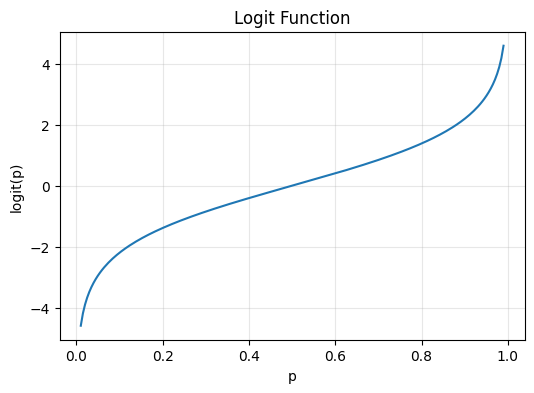

In [3]:
logreg = LogisticRegression(max_iter=1000, solver="liblinear")
logreg.fit(X, y)

pred_logreg = logreg.predict(X)
prob_logreg = logreg.predict_proba(X)[:, 1]

print("Logistic regression accuracy:", round(accuracy_score(y, pred_logreg), 3))
print("Classes:", logreg.classes_)
print("Intercept:", logreg.intercept_[0])
print("Coefficients:", dict(zip(X.columns, logreg.coef_[0])))

p = np.linspace(0.01, 0.99, 200)
logit = np.log(p / (1 - p))

plt.figure(figsize=(6,4))
plt.plot(p, logit)
plt.xlabel("p")
plt.ylabel("logit(p)")
plt.title("Logit Function")
plt.grid(alpha=0.3)
plt.show()

## Odds Ratio dan Interpretasi Coefficient

Coefficient logistic regression berada pada skala log odds. Agar lebih mudah ditafsirkan, coefficient dapat diubah menjadi odds ratio dengan fungsi eksponensial.

### Rumus Odds Ratio

$$
odds\ ratio = e^{\beta_j}
$$

Jika odds ratio lebih besar dari 1, kenaikan predictor meningkatkan odds outcome kelas 1. Jika odds ratio lebih kecil dari 1, kenaikan predictor menurunkan odds outcome kelas 1.

Logistic regression di-fit menggunakan maximum likelihood estimation, bukan least squares. Model mencari parameter yang paling mungkin menghasilkan data observed.

In [4]:
coef_table = pd.DataFrame({
    "predictor": X.columns,
    "coefficient_log_odds": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0])
})

coef_table

,predictor,coefficient_log_odds,odds_ratio
0,borrower_score,-3.440122,0.032061
1,payment_inc_ratio,0.100984,1.106259


## Evaluating Classification Models

Model classification dievaluasi berdasarkan seberapa baik model mengklasifikasikan data baru. Accuracy sering digunakan, tetapi tidak selalu cukup, terutama jika class distribution tidak seimbang.

Confusion matrix menjadi dasar dari berbagai classification metrics. Matrix ini menunjukkan kombinasi antara actual class dan predicted class.

### Confusion Matrix dan Metric Dasar

Untuk binary classification:

| Actual / Predicted | Predicted 1 | Predicted 0 |
|---|---:|---:|
| Actual 1 | True Positive (TP) | False Negative (FN) |
| Actual 0 | False Positive (FP) | True Negative (TN) |

Accuracy:

$$
Accuracy =
\frac{TP+TN}{TP+TN+FP+FN}
$$

Precision:

$$
Precision =
\frac{TP}{TP+FP}
$$

Recall atau sensitivity:

$$
Recall =
\frac{TP}{TP+FN}
$$

Specificity:

$$
Specificity =
\frac{TN}{TN+FP}
$$

In [5]:
cm = confusion_matrix(y, pred_logreg)
tn, fp, fn, tp = cm.ravel()

metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall / Sensitivity", "Specificity"],
    "value": [
        accuracy_score(y, pred_logreg),
        precision_score(y, pred_logreg),
        recall_score(y, pred_logreg),
        tn / (tn + fp)
    ]
})

conf_mat = pd.DataFrame(
    [[tp, fn], [fp, tn]],
    index=["Y = default", "Y = paid off"],
    columns=["Yhat = default", "Yhat = paid off"]
)

display(conf_mat)
metrics

,Yhat = default,Yhat = paid off
Y = default,248,176
Y = paid off,135,341


,metric,value
0,Accuracy,0.654444
1,Precision,0.647520
2,Recall / Sensitivity,0.584906
3,Specificity,0.716387


## ROC Curve, AUC, dan Lift

ROC curve menampilkan trade-off antara sensitivity dan specificity pada berbagai cutoff probability. Dalam praktik machine learning, ROC sering diplot sebagai True Positive Rate terhadap False Positive Rate.

AUC merangkum kemampuan model membedakan kelas. Nilai AUC yang lebih tinggi menunjukkan model lebih baik dalam memberi ranking probability kepada record positif dibanding negatif.

Lift digunakan ketika kelas 1 relatif rare. Lift mengukur seberapa baik model menemukan kelas penting pada bagian atas ranking probability dibanding pemilihan acak.

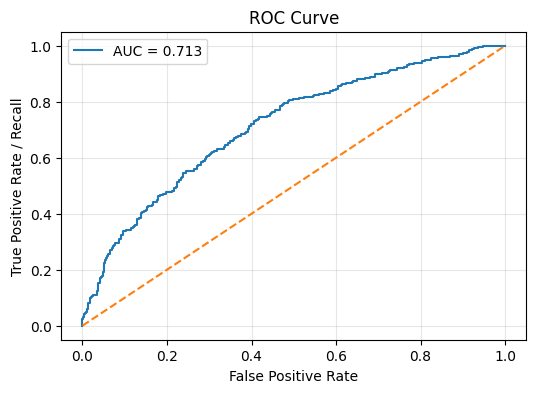

AUC: 0.713
Overall positive rate: 0.471
Top decile positive rate: 0.778
Lift at top decile: 1.651


In [6]:
fpr, tpr, thresholds = roc_curve(y, prob_logreg)
auc = roc_auc_score(y, prob_logreg)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Lift sederhana: default rate pada top decile probability dibanding overall default rate
ranking = pd.DataFrame({"y": y, "prob": prob_logreg}).sort_values("prob", ascending=False)
top_decile = ranking.head(int(len(ranking) * 0.10))

overall_rate = ranking["y"].mean()
top_rate = top_decile["y"].mean()
lift = top_rate / overall_rate

print("AUC:", round(auc, 3))
print("Overall positive rate:", round(overall_rate, 3))
print("Top decile positive rate:", round(top_rate, 3))
print("Lift at top decile:", round(lift, 3))

## The Rare Class Problem

Rare class problem terjadi ketika kelas yang paling penting justru muncul sangat sedikit. Contohnya adalah fraud, loan default, atau pembelian pada website. Dalam kondisi ini, accuracy bisa menyesatkan karena model dapat memperoleh accuracy tinggi hanya dengan memprediksi kelas mayoritas.

Pada rare class problem, false negative sering lebih mahal daripada false positive. Karena itu, cutoff probability, recall, precision, lift, dan cost-based decision menjadi lebih penting dibanding accuracy saja.

## Strategies for Imbalanced Data

Chapter membahas beberapa strategi untuk menangani imbalanced data:

| Strategi | Penjelasan |
|---|---|
| Undersampling | Mengurangi jumlah record kelas mayoritas. |
| Oversampling | Menambah record kelas minoritas melalui sampling with replacement. |
| Up/down weighting | Memberi bobot lebih besar pada rare class atau bobot lebih kecil pada prevalent class. |
| Data generation | Membuat record baru yang sedikit berbeda dari record rare class yang ada. |
| Cost-based classification | Mengubah keputusan berdasarkan biaya false positive dan false negative. |

Weighting sering menjadi alternatif praktis karena mengubah kontribusi error dalam loss function tanpa harus membuang data.

In [7]:
# Simulasi imbalanced data
X_imb, y_imb = make_classification(
    n_samples=3000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    weights=[0.90, 0.10],
    random_state=2024
)

X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imb, test_size=0.30, random_state=2024, stratify=y_imb
)

plain_model = LogisticRegression(max_iter=1000)
plain_model.fit(X_train, y_train)

weighted_model = LogisticRegression(max_iter=1000, class_weight="balanced")
weighted_model.fit(X_train, y_train)

plain_pred = plain_model.predict(X_test)
weighted_pred = weighted_model.predict(X_test)

comparison = pd.DataFrame({
    "model": ["Plain logistic regression", "Weighted logistic regression"],
    "accuracy": [accuracy_score(y_test, plain_pred), accuracy_score(y_test, weighted_pred)],
    "precision": [precision_score(y_test, plain_pred), precision_score(y_test, weighted_pred)],
    "recall": [recall_score(y_test, plain_pred), recall_score(y_test, weighted_pred)],
    "positive_prediction_rate": [plain_pred.mean(), weighted_pred.mean()]
})

comparison

,model,accuracy,precision,recall,positive_prediction_rate
0,Plain logistic regression,0.928889,0.812500,0.414894,0.053333
1,Weighted logistic regression,0.823333,0.339901,0.734043,0.225556


## Cost-Based Classification dan Exploring Predictions

Classification tidak selalu hanya soal memilih cutoff 0.5. Dalam aplikasi bisnis, setiap jenis error dapat memiliki biaya berbeda. Jika false negative lebih mahal, cutoff dapat diturunkan agar model menangkap lebih banyak kelas positif. Jika false positive lebih mahal, cutoff dapat dinaikkan agar prediksi positif lebih selektif.

Exploring predictions dilakukan dengan melihat distribusi probability score dan memeriksa record yang berada di sekitar cutoff atau record dengan probability sangat tinggi. Proses ini membantu memahami bagaimana model membuat keputusan.

In [8]:
cutoffs = [0.3, 0.5, 0.7]
prob_test = weighted_model.predict_proba(X_test)[:, 1]

rows = []
for cutoff in cutoffs:
    pred_cutoff = (prob_test >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_cutoff).ravel()
    rows.append({
        "cutoff": cutoff,
        "precision": precision_score(y_test, pred_cutoff),
        "recall": recall_score(y_test, pred_cutoff),
        "specificity": tn / (tn + fp),
        "positive_prediction_rate": pred_cutoff.mean()
    })

pd.DataFrame(rows)

,cutoff,precision,recall,specificity,positive_prediction_rate
0,0.3,0.190955,0.808511,0.600496,0.442222
1,0.5,0.339901,0.734043,0.833747,0.225556
2,0.7,0.515152,0.542553,0.940447,0.110000


## Hubungan Antar Konsep

| Konsep | Deskripsi |
|---|---|
| Classification | Prediksi outcome berbentuk kelas. |
| Probability cutoff | Batas untuk mengubah probability menjadi class label. |
| Naive Bayes | Menggunakan conditional probability dan asumsi independence antar predictor. |
| LDA | Mencari linear discriminant function yang memisahkan kelas. |
| Logistic regression | Memodelkan log odds dari binary outcome. |
| Odds ratio | Interpretasi coefficient logistic regression pada skala odds. |
| Confusion matrix | Dasar evaluasi classification melalui TP, TN, FP, dan FN. |
| Precision | Seberapa banyak prediksi positif yang benar-benar positif. |
| Recall | Seberapa banyak actual positive yang berhasil ditemukan. |
| Specificity | Seberapa banyak actual negative yang benar teridentifikasi. |
| ROC dan AUC | Evaluasi ranking probability pada berbagai cutoff. |
| Lift | Ukuran efektivitas model dalam menemukan rare class pada ranking atas. |
| Imbalanced data | Kondisi ketika kelas penting jauh lebih sedikit dari kelas lain. |

## Kesimpulan Chapter

Chapter ini menjelaskan classification sebagai metode supervised learning untuk memprediksi kelas atau kategori suatu record. Dalam banyak aplikasi, model classification tidak hanya menghasilkan label kelas, tetapi juga probability score yang dapat diubah menjadi keputusan menggunakan cutoff tertentu.

Naive Bayes menggunakan conditional probability untuk menghitung kemungkinan suatu outcome berdasarkan predictor values. Metode ini sederhana dan efisien, tetapi bergantung pada asumsi independence antar predictor.

Discriminant Analysis, khususnya LDA, menggunakan covariance matrix dan discriminant function untuk memisahkan kelas. LDA mencari kombinasi linear predictor yang memaksimalkan pemisahan antar kelas dan meminimalkan variasi dalam kelas.

Logistic regression memodelkan binary outcome melalui log odds dan logistic response function. Model ini populer karena cepat dihitung, mudah diinterpretasikan melalui odds ratio, dan dapat langsung digunakan untuk scoring data baru.

Evaluasi classification tidak cukup hanya menggunakan accuracy, terutama ketika data tidak seimbang. Confusion matrix, precision, recall, specificity, ROC curve, AUC, dan lift memberikan gambaran performa yang lebih lengkap. Untuk imbalanced data, strategi seperti undersampling, oversampling, weighting, data generation, dan cost-based classification dapat digunakan agar model lebih sesuai dengan tujuan analisis.